In [5]:
import pandas as pd

In [8]:
df = pd.read_csv("C:/Users/ohabi/OneDrive/Desktop/MRLF DATA FELLOW ASSIGNMENTS/DATA FOR CORRELATION TEST QUERY 2.csv")

In [9]:
df.head()

,Constituency_Name,District,BPL_Households_Pct,JJM_Functional_Tap_Connections_Pct,PM_Awas_Completion_Pct,Literacy_Rate_Pct,Pucca_Road_Pct,Internet_4G_Coverage_Pct,Road_Length_Km
0,Mawlai,East Khasi Hills,26.7,63.0,64.8,87.9,82.6,87.6,48.1
1,Pynthorumkhrah,East Khasi Hills,18.7,88.6,73.4,94.4,83.4,83.4,78.8
2,Nongthymmai,East Khasi Hills,21.1,85.2,76.5,84.3,71.8,78.9,76.0
3,Shillong East,East Khasi Hills,12.6,90.9,89.3,84.0,86.4,73.4,53.9
4,Shillong West,East Khasi Hills,21.9,84.5,52.5,94.1,79.6,78.1,70.8


In [11]:
from scipy.stats import spearmanr

In [12]:
#Correlation BPL vs JJM
corr_jjm, p_jjm = spearmanr(
    df['BPL_Households_Pct'],
    df['JJM_Functional_Tap_Connections_Pct']
)


In [13]:
# BPL vs PMAY
corr_pmay, p_pmay = spearmanr(
    df['BPL_Households_Pct'],
    df['PM_Awas_Completion_Pct']
)

In [14]:
print("BPL vs JJM:", corr_jjm, p_jjm)
print("BPL vs PMAY:", corr_pmay, p_pmay)

BPL vs JJM: -0.42923040588806755 0.0006212845424787475
BPL vs PMAY: 0.04854665703329073 0.7126139867453707


In [15]:
import statsmodels.formula.api as smf

In [16]:
jjm_model = smf.ols(
    'JJM_Functional_Tap_Connections_Pct ~ BPL_Households_Pct + Literacy_Rate_Pct + Pucca_Road_Pct + Internet_4G_Coverage_Pct',
    data=df
).fit()


In [17]:
print(jjm_model.summary())

                                    OLS Regression Results                                    
Dep. Variable:     JJM_Functional_Tap_Connections_Pct   R-squared:                       0.455
Model:                                            OLS   Adj. R-squared:                  0.416
Method:                                 Least Squares   F-statistic:                     11.49
Date:                                Sat, 20 Jun 2026   Prob (F-statistic):           7.54e-07
Time:                                        19:14:39   Log-Likelihood:                -245.75
No. Observations:                                  60   AIC:                             501.5
Df Residuals:                                      55   BIC:                             512.0
Df Model:                                           4                                         
Covariance Type:                            nonrobust                                         
                               coef    std err    

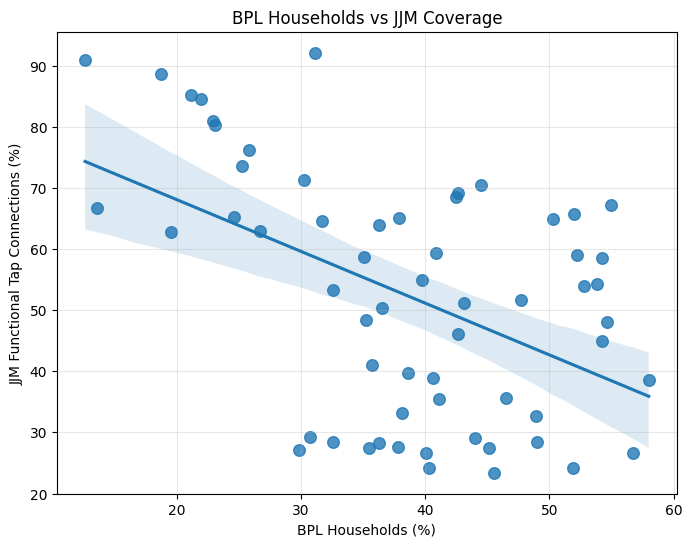

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='BPL_Households_Pct',
    y='JJM_Functional_Tap_Connections_Pct',
    scatter_kws={'s':70}
)

plt.title('BPL Households vs JJM Coverage')
plt.xlabel('BPL Households (%)')
plt.ylabel('JJM Functional Tap Connections (%)')
plt.grid(alpha=0.3)

plt.show()

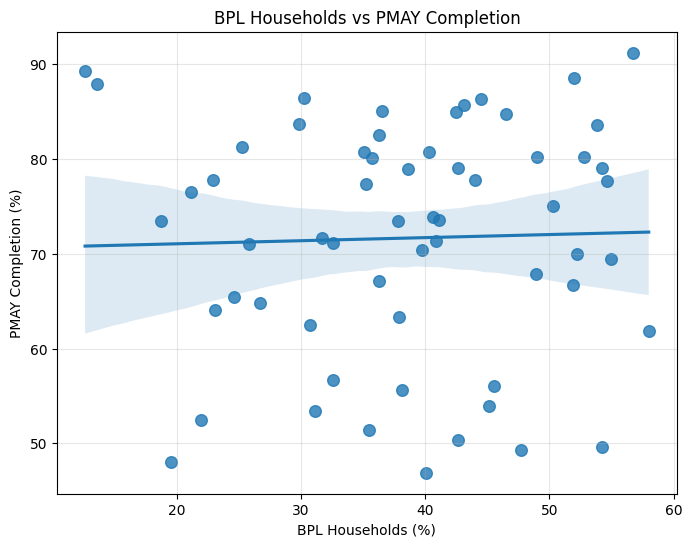

In [21]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='BPL_Households_Pct',
    y='PM_Awas_Completion_Pct',
    scatter_kws={'s':70}
)

plt.title('BPL Households vs PMAY Completion')
plt.xlabel('BPL Households (%)')
plt.ylabel('PMAY Completion (%)')
plt.grid(alpha=0.3)

plt.show()

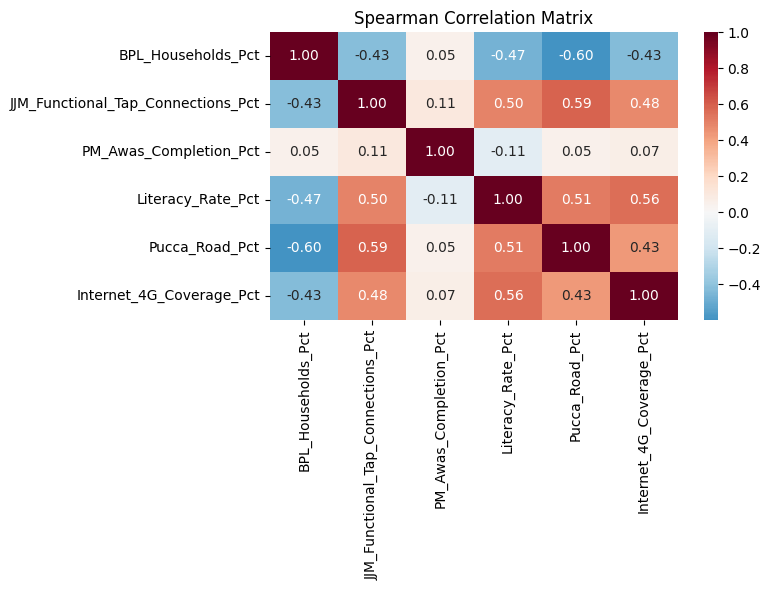

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_vars = [
    'BPL_Households_Pct',
    'JJM_Functional_Tap_Connections_Pct',
    'PM_Awas_Completion_Pct',
    'Literacy_Rate_Pct',
    'Pucca_Road_Pct',
    'Internet_4G_Coverage_Pct'
]

corr_matrix = df[corr_vars].corr(method='spearman')

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f'
)

plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

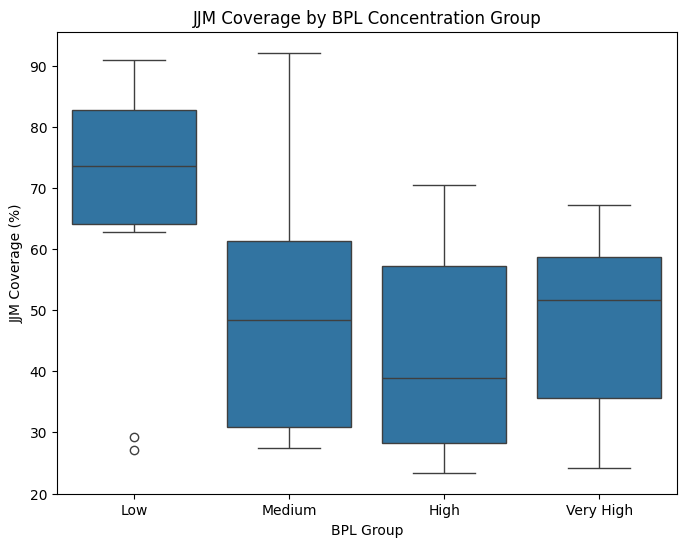

In [23]:
df['BPL_Group'] = pd.qcut(
    df['BPL_Households_Pct'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='BPL_Group',
    y='JJM_Functional_Tap_Connections_Pct'
)

plt.title('JJM Coverage by BPL Concentration Group')
plt.xlabel('BPL Group')
plt.ylabel('JJM Coverage (%)')

plt.show()

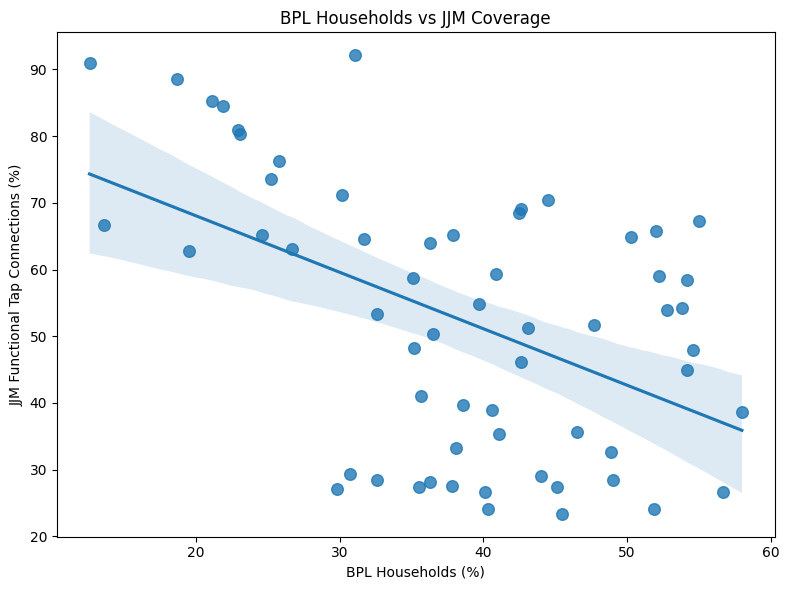

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='BPL_Households_Pct',
    y='JJM_Functional_Tap_Connections_Pct',
    scatter_kws={'s':70}
)

plt.title('BPL Households vs JJM Coverage')
plt.xlabel('BPL Households (%)')
plt.ylabel('JJM Functional Tap Connections (%)')

plt.tight_layout()

plt.savefig(
    "BPL_vs_JJM_Correlation.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

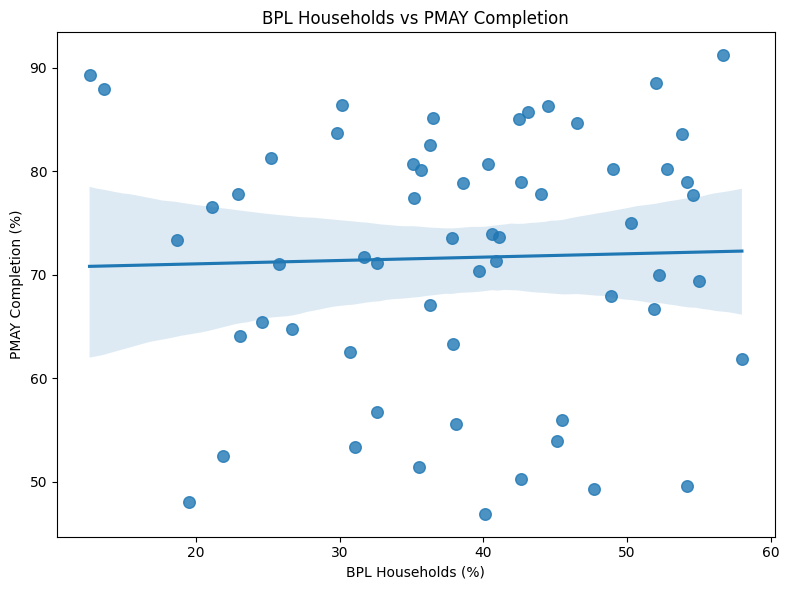

In [25]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='BPL_Households_Pct',
    y='PM_Awas_Completion_Pct',
    scatter_kws={'s':70}
)

plt.title('BPL Households vs PMAY Completion')
plt.xlabel('BPL Households (%)')
plt.ylabel('PMAY Completion (%)')

plt.tight_layout()

plt.savefig(
    "BPL_vs_PMAY_Correlation.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

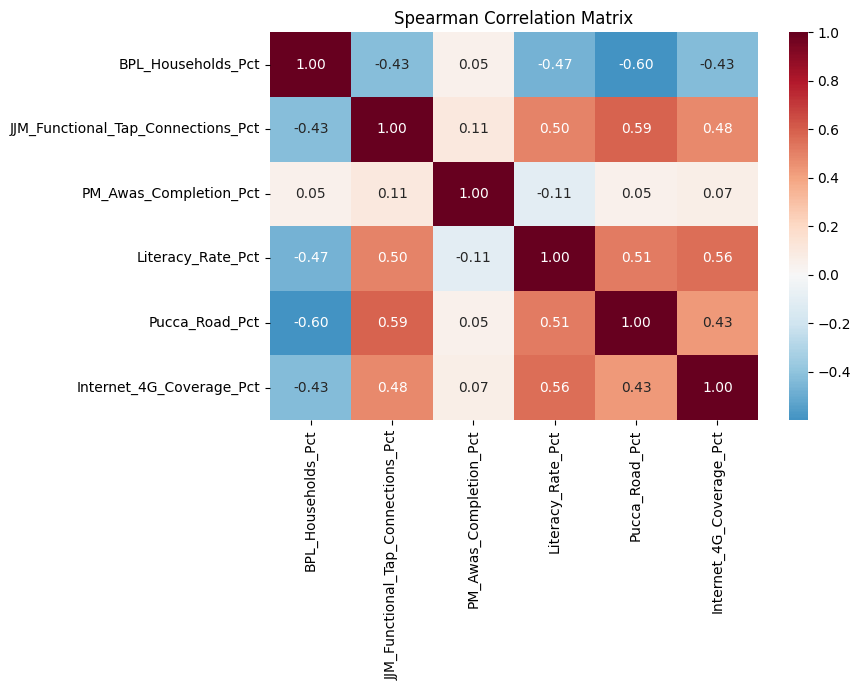

In [26]:
corr_vars = [
    'BPL_Households_Pct',
    'JJM_Functional_Tap_Connections_Pct',
    'PM_Awas_Completion_Pct',
    'Literacy_Rate_Pct',
    'Pucca_Road_Pct',
    'Internet_4G_Coverage_Pct'
]

corr_matrix = df[corr_vars].corr(method='spearman')

plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f'
)

plt.title('Spearman Correlation Matrix')

plt.tight_layout()

plt.savefig(
    "Correlation_Heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

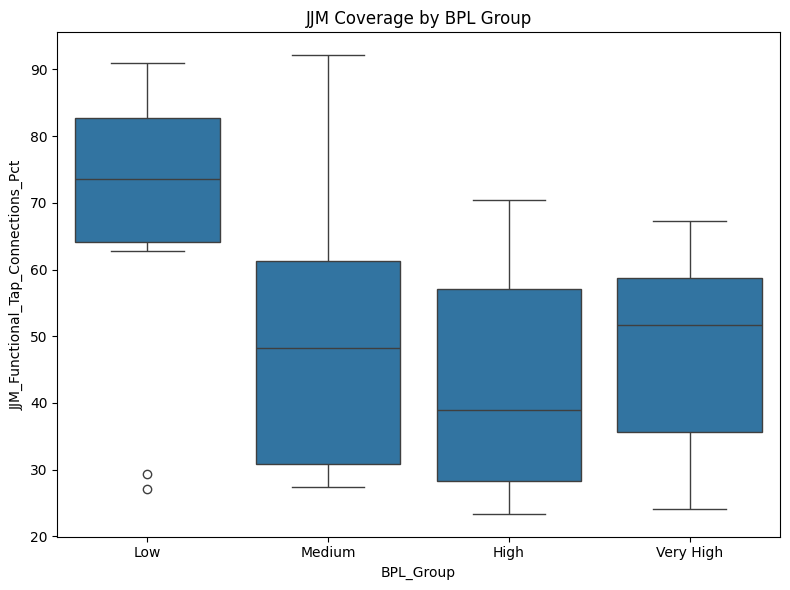

In [27]:
df['BPL_Group'] = pd.qcut(
    df['BPL_Households_Pct'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='BPL_Group',
    y='JJM_Functional_Tap_Connections_Pct'
)

plt.title('JJM Coverage by BPL Group')

plt.tight_layout()

plt.savefig(
    "JJM_BPL_Boxplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [28]:
import os

os.makedirs("Plots", exist_ok=True)

In [29]:
plt.savefig(
    "Plots/BPL_vs_JJM_Correlation.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [30]:
plt.savefig(
    "Plots/BPL_vs_JJM_Correlation.png",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "Plots/BPL_vs_JJM_Correlation.pdf",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>